Предмет "Искусственный интеллект"

Лабораторные работы №6 и №7

Грибушенков Михаил, группа РФЗ-2-2022

Устранение дисбаланса в наборе данных про запрос страховки туристами в зависимости от параметров поездки.

**Л/Р № 6**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

# defines
filename = "travelinsuranceclaimstatus.csv"

In [50]:
db = pd.read_csv (filename, sep=",") # Загрузка базы данных из файла
db = db.drop("ID", axis = 1)
db.info() # Статистика по БД
db.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62288 entries, 0 to 62287
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   62288 non-null  int64  
 1   Agency                62288 non-null  object 
 2   Agency Type           62288 non-null  object 
 3   Commision (in value)  62288 non-null  float64
 4   Destination           62288 non-null  object 
 5   Distribution Channel  62288 non-null  object 
 6   Duration              62288 non-null  int64  
 7   Gender                22713 non-null  object 
 8   Net Sales             62288 non-null  float64
 9   Product Name          62288 non-null  object 
 10  Claim                 62288 non-null  int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 5.2+ MB


,Age,Agency,Agency Type,Commision (in value),Destination,Distribution Channel,Duration,Gender,Net Sales,Product Name,Claim
0,28,C2B,Airlines,28.13,SINGAPORE,Online,34,F,112.50,Silver Plan,1
1,37,JZI,Airlines,12.95,PHILIPPINES,Online,53,F,37.00,Basic Plan,0
2,27,EPX,Travel Agency,0.00,UNITED STATES,Online,28,NaN,13.00,Cancellation Plan,0
3,36,EPX,Travel Agency,0.00,SAUDI ARABIA,Online,1,NaN,34.00,Cancellation Plan,0
4,26,CWT,Travel Agency,23.76,THAILAND,Online,33,NaN,39.60,Rental Vehicle Excess Insurance,0
5,39,CWT,Travel Agency,59.40,AUSTRALIA,Online,78,NaN,99.00,Rental Vehicle Excess Insurance,0
6,34,CWT,Travel Agency,23.76,AUSTRALIA,Online,27,NaN,0.00,Rental Vehicle Excess Insurance,0
7,45,JZI,Airlines,9.10,HONG KONG,Online,10,M,26.00,Basic Plan,0
8,32,C2B,Airlines,63.21,SINGAPORE,Online,368,M,252.85,Annual Silver Plan,1
9,59,C2B,Airlines,63.21,SINGAPORE,Online,377,F,252.85,Annual Silver Plan,0


In [25]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 1.2 MB/s eta 0:00:00


In [74]:
# Кодирование бинарное: места назначения, имени страхового продукта и турагенства

from category_encoders.binary import BinaryEncoder

encoder = BinaryEncoder()
encoded_destination = encoder.fit_transform(db[["Destination"]])
db2 = db.join(encoded_destination, how="right").drop("Destination", axis = 1)

encoded_agency = encoder.fit_transform(db[["Agency"]])
db2 = db2.join(encoded_agency, how="right").drop("Agency", axis = 1)

encoded_agency = encoder.fit_transform(db[["Product Name"]])
db2 = db2.join(encoded_agency, how="right").drop("Product Name", axis = 1)

# онехотенкодер типа агенства и distribution channel.

db2 = db2.join(pd.get_dummies(db["Agency Type"]).replace({False: 0, True: 1}), how = "right").drop("Agency Type", axis = 1)
db2 = db2.join(pd.get_dummies(db["Distribution Channel"]).replace({False: 0, True: 1}), how = "right").drop("Distribution Channel", axis = 1)

# Нормализация столбца пола...
db2["Gender"] = db2["Gender"].fillna(0.5).replace({"M": 1, "F": 0})

db2.head (10)

/tmp/ipykernel_30778/3878070884.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  db2 = db2.join(pd.get_dummies(db["Agency Type"]).replace({False: 0, True: 1}), how = "right").drop("Agency Type", axis = 1)
/tmp/ipykernel_30778/3878070884.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  db2 = db2.join(pd.get_dummies(db["Distribution Channel"]).replace({False: 0, True: 1}), how = "right").drop("Distribution Channel", axis = 1)
/tmp/ipykernel_30778/3878070884.py:21: FutureWarning: Downcasting behavior in `replace` is deprecate

,Age,Commision (in value),Duration,Gender,Net Sales,Claim,Destination_0,Destination_1,Destination_2,Destination_3,...,Agency_4,Product Name_0,Product Name_1,Product Name_2,Product Name_3,Product Name_4,Airlines,Travel Agency,Offline,Online
0,28,28.13,34,0.0,112.50,1,0,0,0,0,...,1,0,0,0,0,1,1,0,0,1
1,37,12.95,53,0.0,37.00,0,0,0,0,0,...,0,0,0,0,1,0,1,0,0,1
2,27,0.00,28,0.5,13.00,0,0,0,0,0,...,1,0,0,0,1,1,0,1,0,1
3,36,0.00,1,0.5,34.00,0,0,0,0,0,...,1,0,0,0,1,1,0,1,0,1
4,26,23.76,33,0.5,39.60,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,1
5,39,59.40,78,0.5,99.00,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,1
6,34,23.76,27,0.5,0.00,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,1
7,45,9.10,10,1.0,26.00,0,0,0,0,0,...,0,0,0,0,1,0,1,0,0,1
8,32,63.21,368,1.0,252.85,1,0,0,0,0,...,1,0,0,1,0,1,1,0,0,1
9,59,63.21,377,0.0,252.85,0,0,0,0,0,...,1,0,0,1,0,1,1,0,0,1


Теперь датасет пригоден для работы.

<Axes: >

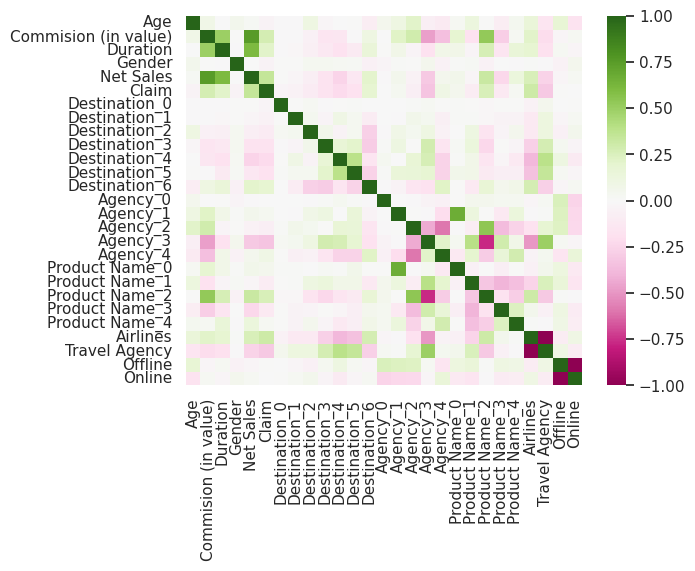

In [60]:
sns.heatmap(db2.corr(numeric_only = True), cmap="PiYG", xticklabels = 1, yticklabels = 1)

С чем-то запрос или незапрос страховки коррелирует, с чем-то - не очень. Из числовых небулевых признаков коррелирует с comission, duration, net sales.

Text(0.5, 1.0, 'Корреляция страховки с продажами')

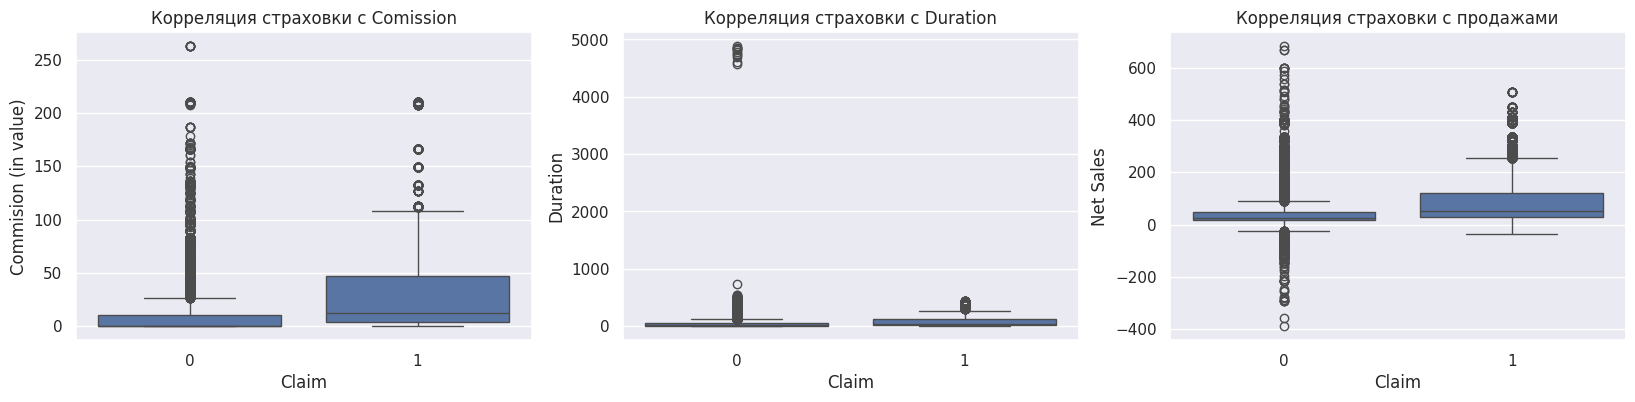

In [75]:
f, axes = plt.subplots(ncols=3, figsize=(20,4))

sns.boxplot(x="Claim", y="Commision (in value)", data=db2, ax=axes[0])
axes[0].set_title("Корреляция страховки с Comission")

sns.boxplot(x="Claim", y="Duration", data=db2, ax=axes[1])
axes[1].set_title("Корреляция страховки с Duration")

sns.boxplot(x="Claim", y="Net Sales", data=db2, ax=axes[2])
axes[2].set_title("Корреляция страховки с продажами")

А выбросы пусть будут, в них важная информация, не хочется ее терять. Кроме duration.

<Axes: xlabel='Claim', ylabel='Duration'>

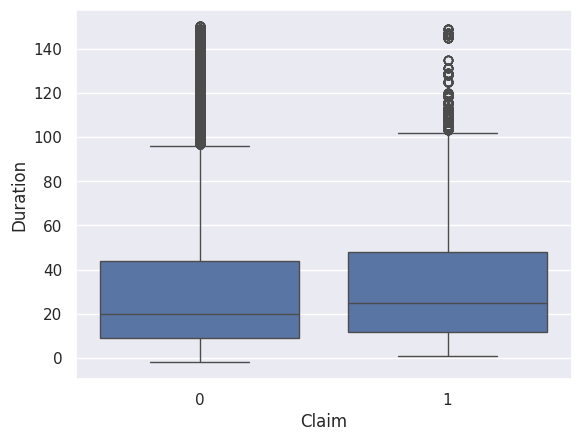

In [73]:
# Удаление выбросов из длительности поездки

Q1, Q3 = db2["Duration"].quantile([0.15, 0.85])
IQR = Q3 - Q1
low, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

db2_new = db2[(db2["Duration"] > low) & (db2["Duration"] < hi)]

sns.boxplot(x="Claim", y="Duration", data=db2_new)

Было лучше c выбросами, не будем удалять.

Text(0.5, 1.0, 'Распределение классов')

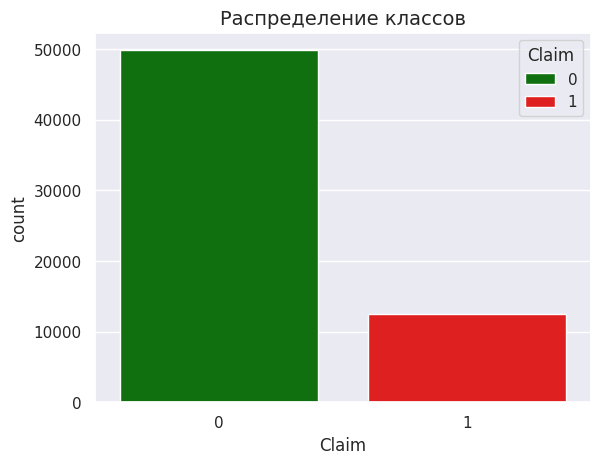

In [58]:
colors = ["green", "red"]

sns.countplot(x="Claim", data=db2, hue="Claim", palette=colors)
plt.title("Распределение классов", fontsize=14)

Видно, что датасет не очень сбалансирован.

In [103]:
# Деление на обучающий и проверочный наборы данных.

from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(db2.drop("Claim", axis=1), db2["Claim"], test_size=0.2, random_state = 7388)

# Нормализация некоторых столбцов
for column in ["Age", "Commision (in value)", "Duration", "Net Sales"]:
    xtrain[column] = xtrain[column] / xtrain[column].abs().max()
    xtest[column] = xtest[column] / xtest[column].abs().max()


In [82]:
xtrain.head(3)

,Age,Commision (in value),Duration,Gender,Net Sales,Destination_0,Destination_1,Destination_2,Destination_3,Destination_4,...,Agency_4,Product Name_0,Product Name_1,Product Name_2,Product Name_3,Product Name_4,Airlines,Travel Agency,Offline,Online
1616,0.313559,0.000000,0.004917,0.5,0.014663,0,0,0,0,0,...,1,0,0,0,1,1,0,1,0,1
1371,0.228814,0.019257,0.001229,1.0,0.029692,0,0,0,0,0,...,1,0,0,1,1,0,1,0,0,1
17640,0.305085,0.000000,0.002049,0.5,0.045455,0,0,1,0,1,...,1,0,0,0,1,1,0,1,0,1


In [79]:
xtest.head(3)

,Age,Commision (in value),Duration,Gender,Net Sales,Destination_0,Destination_1,Destination_2,Destination_3,Destination_4,...,Agency_4,Product Name_0,Product Name_1,Product Name_2,Product Name_3,Product Name_4,Airlines,Travel Agency,Offline,Online
23910,0.271186,0.000000,0.004599,0.5,0.028381,0,0,1,0,1,...,1,0,0,0,1,1,0,1,0,1
47455,0.237288,0.256886,0.080477,0.0,0.360601,0,0,0,0,0,...,1,0,0,1,0,1,1,0,0,1
47596,0.305085,0.000000,0.002926,0.5,0.050083,0,0,0,1,0,...,1,0,1,0,0,0,0,1,0,1


In [80]:
ytrain.head(3)

,Claim
1616,0
1371,0
17640,0


In [81]:
ytest.head(3)

,Claim
23910,1
47455,1
47596,1


Работает.

Text(0.5, 1.0, 'Распределение классов в обучающем наборе данных')

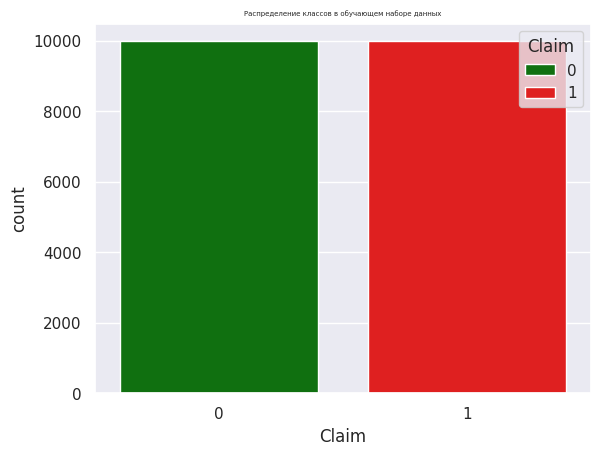

In [110]:
# Ундерсемплинг набора данных для обучения.

amount = sum(ytrain)  # Количество запросов страховки

train = xtrain.copy()
train["Claim"] = ytrain
train_claimed = train.loc[train["Claim"] == 1]
train_unclaimed = ( train.loc[train["Claim"] == 0].sample(frac=1) ) [:amount]
train = pd.concat ([train_claimed, train_unclaimed]).sample(frac=1)

colors = ["green", "red"]
sns.countplot(x="Claim", data=train, hue="Claim", palette=colors)
plt.title("Распределение классов в обучающем наборе данных", fontsize=5)

In [111]:
xtrain_undersampled = train.drop("Claim", axis = 1)
ytrain_undersampled = train["Claim"]

In [113]:
# Понижение размерности и кластеризация после андерсемлинга для проверки разделимости

import time
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, TruncatedSVD

# # T-SNE алгоритм
# t0 = time.time()
# X_reduced_tsne = TSNE(n_components=2, random_state=73).fit_transform(xtrain_undersampled.values)
# t1 = time.time()
# print("T-SNE заняло {:.2} сек".format(t1 - t0))

# PCA алгоритм
t0 = time.time()
X_reduced_pca = PCA(n_components=2, random_state=73).fit_transform(xtrain_undersampled.values)
t1 = time.time()
print("PCA заняло {:.2} сек".format(t1 - t0))

# TruncatedSVD алгоритм
t0 = time.time()
X_reduced_svd = TruncatedSVD(n_components=2, algorithm='randomized', random_state=73).fit_transform(xtrain_undersampled.values)
t1 = time.time()
print("Truncated SVD заняло {:.2} сек".format(t1 - t0))

PCA заняло 0.027 сек
Truncated SVD заняло 0.12 сек


A t-sne работало полтора часа, после чего мне надоело ждать. Извините.

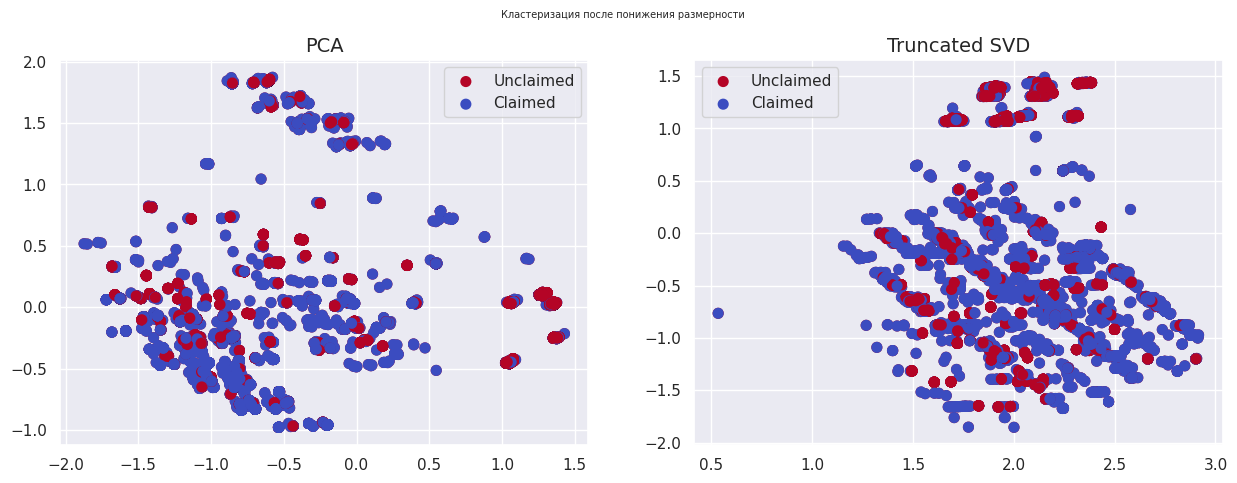

In [118]:
import matplotlib.patches as mpatches

f, (ax2, ax3) = plt.subplots(1, 2, figsize=(15,5))
f.suptitle('Кластеризация после понижения размерности', fontsize=7)

# # t-SNE scatter plot
# ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y == 0), cmap='coolwarm', label='Non Fraud', linewidths=2)
# ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y == 1), cmap='coolwarm', label='Fraud', linewidths=2)
# ax1.set_title('t-SNE', fontsize=14)

# ax1.grid(True)

# ax1.legend(handles=[red_patch, green_patch])


# PCA scatter plot
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=(ytrain_undersampled == 0), cmap='coolwarm', label="Unclaimed", linewidths=2)
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=(ytrain_undersampled == 1), cmap='coolwarm', label="Claimed", linewidths=2)
ax2.set_title('PCA', fontsize=14)

ax2.grid(True)
ax2.legend()

# TruncatedSVD scatter plot
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=(ytrain_undersampled == 0), cmap='coolwarm', label="Unclaimed", linewidths=2)
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=(ytrain_undersampled == 1), cmap='coolwarm', label="Claimed", linewidths=2)
ax3.set_title('Truncated SVD', fontsize=14)

ax3.grid(True)
ax3.legend()

plt.show()

Не очень разделимое, но какое есть.

**Л/Р № 7**

In [122]:
# Проверка работы простых моделей на ундерсемплнутом датасете

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

classifiers = {
    "Логистическая регрессия": LogisticRegression(),
    "Метод опорных векторов": SVC(),
    "Метод К ближайших соседей": KNeighborsClassifier(),
    "Метод дерева решений": DecisionTreeClassifier()
}

for key, classifier in classifiers.items():
    classifier.fit(xtrain_undersampled, ytrain_undersampled)
    training_score = cross_val_score(classifier, xtest.values, ytest.values, cv=5)
    print("Модель ", key, "получила на ТеСтОвОй выборке", round(training_score.mean(), 2) * 100, "% accuracy score")

Модель  Логистическая регрессия получила на ТеСтОвОй выборке 82.0 % accuracy score
Модель  Метод опорных векторов получила на ТеСтОвОй выборке 82.0 % accuracy score
Модель  Метод К ближайших соседей получила на ТеСтОвОй выборке 85.0 % accuracy score
Модель  Метод дерева решений получила на ТеСтОвОй выборке 92.0 % accuracy score


Дерево работает лучше всего, метод опорных векторов работает плохо и на порядок дольше всех.

In [135]:
# Используем поиск по сетке для подбора гиперпараметров
from sklearn.model_selection import GridSearchCV

# Логистическая регрессия
log_reg_params = {"penalty": ['l1', 'l2'], 'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}

grid_log_reg = GridSearchCV(LogisticRegression(max_iter=1000), log_reg_params)
grid_log_reg.fit(xtrain_undersampled, ytrain_undersampled)
log_reg = grid_log_reg.best_estimator_

# Метод ближайших соседей
knears_params = {"n_neighbors": list(range(2,7,1)), 'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']}
grid_knears = GridSearchCV(KNeighborsClassifier(), knears_params)
grid_knears.fit(xtrain_undersampled, ytrain_undersampled)
knears_neighbors = grid_knears.best_estimator_

# Не хочу использовать метод опорных векторов, он работает на данном датасете плохо и крайне медленно.
# # Метод опорных векторов
# x = [1.0, 1000.0]
# y = [0.9]
# z = [4]
# svc_params=[
#             {'C': x,'kernel': ['rbf'],'gamma': y} ,
#             {'C': x,'kernel': ['poly'],'gamma': y,'degree': z}
#            ]
# grid_svc=GridSearchCV(estimator = SVC(),
#                         param_grid = svc_params,
#                         scoring='accuracy',
#                         cv=3,
#                         n_jobs=-1)
# grid_svc.fit(X_train, y_train)
# svc = grid_svc.best_estimator_#  для SVM

# Решающее дерево
tree_params = {"criterion": ["gini", "entropy"], "max_depth": list(range(2,7,1)),
              "min_samples_leaf": list(range(5,7,1))}
grid_tree = GridSearchCV(DecisionTreeClassifier(), tree_params)
grid_tree.fit(xtrain_undersampled, ytrain_undersampled)
tree_clf = grid_tree.best_estimator_

classifiers = {
    "Логистическая регрессия": log_reg,
    "Метод К ближайших соседей": knears_neighbors,
    "Метод дерева решений": tree_clf
}

for key, classifier in classifiers.items():
    training_score = cross_val_score(classifier, xtest.values, ytest.values, cv=5)
    print("Модель ", key, "получила на ТеСтОвОй выборке", round(training_score.mean(), 2) * 100, "% accuracy score")

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
35 fits failed out of a total of 70.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
35 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    solver = _check_solver

Модель  Логистическая регрессия получила на ТеСтОвОй выборке 82.0 % accuracy score
Модель  Метод К ближайших соседей получила на ТеСтОвОй выборке 90.0 % accuracy score
Модель  Метод дерева решений получила на ТеСтОвОй выборке 83.0 % accuracy score


Ругается, но работает. К ближайших соседей сработали лучше, чем без подбора гиперпараметров, но дерево без подбора все равно лучше и быстрее.

In [136]:
# Ундерсэмплинг методом NearMiss вместо случайного

from imblearn.pipeline import make_pipeline as imbalanced_make_pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
from imblearn.metrics import classification_report_imbalanced
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, random_state=None, shuffle=False)

from sklearn.metrics import (precision_score, roc_auc_score, recall_score, f1_score, classification_report,
                             confusion_matrix, roc_curve, precision_recall_curve, accuracy_score)

undersample_X = db2.drop("Claim", axis=1)
undersample_y = db2["Claim"]

undersample_Xtrain, undersample_Xtest, undersample_ytrain, undersample_ytest = train_test_split(undersample_X, undersample_y,
                                                                                                test_size = 0.2,
                                                                                                random_state=42,
                                                                                                stratify = undersample_y)#

# Нормализация некоторых столбцов
for column in ["Age", "Commision (in value)", "Duration", "Net Sales"]:
    undersample_Xtrain[column] = undersample_Xtrain[column] / undersample_Xtrain[column].abs().max()
    undersample_Xtrain[column] = undersample_Xtrain[column] / undersample_Xtrain[column].abs().max()

undersample_Xtrain = undersample_Xtrain.values
undersample_Xtest = undersample_Xtest.values
undersample_ytrain = undersample_ytrain.values
undersample_ytest = undersample_ytest.values

undersample_accuracy = []
undersample_precision = []
undersample_recall = []
undersample_f1 = []
undersample_auc = []

# Метод NearMiss
X_nearmiss, y_nearmiss = NearMiss().fit_resample(undersample_X.values, undersample_y.values)
print('NearMiss распределение классов: ', len(y_nearmiss) - sum(y_nearmiss), "---", sum(y_nearmiss))

for train, test in skf.split(undersample_Xtrain, undersample_ytrain):
    undersample_pipeline = imbalanced_make_pipeline(NearMiss(sampling_strategy='majority'), log_reg)#
    undersample_model = undersample_pipeline.fit(undersample_Xtrain[train], undersample_ytrain[train])#
    undersample_prediction = undersample_model.predict(undersample_Xtrain[test])#

    undersample_accuracy.append(undersample_pipeline.score(undersample_Xtrain[test],
                                                           undersample_ytrain[test]))
    undersample_precision.append(precision_score(undersample_ytrain[test], undersample_prediction))
    undersample_recall.append(recall_score(undersample_ytrain[test], undersample_prediction))
    undersample_f1.append(f1_score(undersample_ytrain[test], undersample_prediction))
    undersample_auc.append(roc_auc_score(undersample_ytrain[test], undersample_prediction))

NearMiss распределение классов:  12458 --- 12458


In [137]:
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import learning_curve

In [147]:
# Кривые обучения моделей

def plot_learning_curves(estimator1, estimator2, estimator4, X, y, ylim=None, cv=None,
                        n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 5)):
    f, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, figsize=(20,14), sharey=True)
    if ylim is not None:
        plt.ylim(*ylim)

    # Первая модель
    train_sizes, train_scores, test_scores = learning_curve(estimator1, X, y, cv=cv,
                                                            n_jobs=n_jobs, train_sizes=train_sizes)#
    train_scores_mean = np.mean(train_scores, axis=1)#
    train_scores_std = np.std(train_scores, axis=1)#
    test_scores_mean = np.mean(test_scores, axis=1)#
    test_scores_std = np.std(test_scores, axis=1)#
    ax1.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="#ff9124")
    ax1.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="#2492ff")
    ax1.plot(train_sizes, train_scores_mean, 'o-', color="#ff9124",
             label="Training score")
    ax1.plot(train_sizes, test_scores_mean, 'o-', color="#2492ff",
             label="Cross-validation score")
    ax1.set_title("Logistic Regression Learning Curve", fontsize=14)
    ax1.set_xlabel('Размер выборки')
    ax1.set_ylabel('Score')
    ax1.grid(True)
    ax1.legend(loc="best")

    # Вторая модель
    train_sizes, train_scores, test_scores = learning_curve(
        estimator2, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    ax2.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="#ff9124")
    ax2.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="#2492ff")
    ax2.plot(train_sizes, train_scores_mean, 'o-', color="#ff9124",
             label="Training score")
    ax2.plot(train_sizes, test_scores_mean, 'o-', color="#2492ff",
             label="Cross-validation score")
    ax2.set_title("Knears Neighbors Learning Curve", fontsize=14)
    ax2.set_xlabel('Размер выборки')
    ax2.set_ylabel('Score')
    ax2.grid(True)
    ax2.legend(loc="best")


    # # Третья модель
    # train_sizes, train_scores, test_scores = learning_curve(
    #     estimator3, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    # train_scores_mean = np.mean(train_scores, axis=1)
    # train_scores_std = np.std(train_scores, axis=1)
    # test_scores_mean = np.mean(test_scores, axis=1)
    # test_scores_std = np.std(test_scores, axis=1)
    # ax3.fill_between(train_sizes, train_scores_mean - train_scores_std,
    #                  train_scores_mean + train_scores_std, alpha=0.1,
    #                  color="#ff9124")
    # ax3.fill_between(train_sizes, test_scores_mean - test_scores_std,
    #                  test_scores_mean + test_scores_std, alpha=0.1, color="#2492ff")
    # ax3.plot(train_sizes, train_scores_mean, 'o-', color="#ff9124",
    #          label="Размер выборки")
    # ax3.plot(train_sizes, test_scores_mean, 'o-', color="#2492ff",
    #          label="Cross-validation score")
    # ax3.set_title("Support Vector Classifier \n Learning Curve", fontsize=14)
    # ax3.set_xlabel('Training size (m)')
    # ax3.set_ylabel('Score')
    # ax3.grid(True)
    # ax3.legend(loc="best")


    # Четвертая модель
    train_sizes, train_scores, test_scores = learning_curve(
        estimator4, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    ax4.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="#ff9124")
    ax4.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="#2492ff")
    ax4.plot(train_sizes, train_scores_mean, 'o-', color="#ff9124",
             label="Размер выборки")
    ax4.plot(train_sizes, test_scores_mean, 'o-', color="#2492ff",
             label="Cross-validation score")
    ax4.set_title("Decision Tree Classifier \n Learning Curve", fontsize=14)
    ax4.set_xlabel('Training size (m)')
    ax4.set_ylabel('Score')
    ax4.grid(True)
    ax4.legend(loc="best")

    return plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

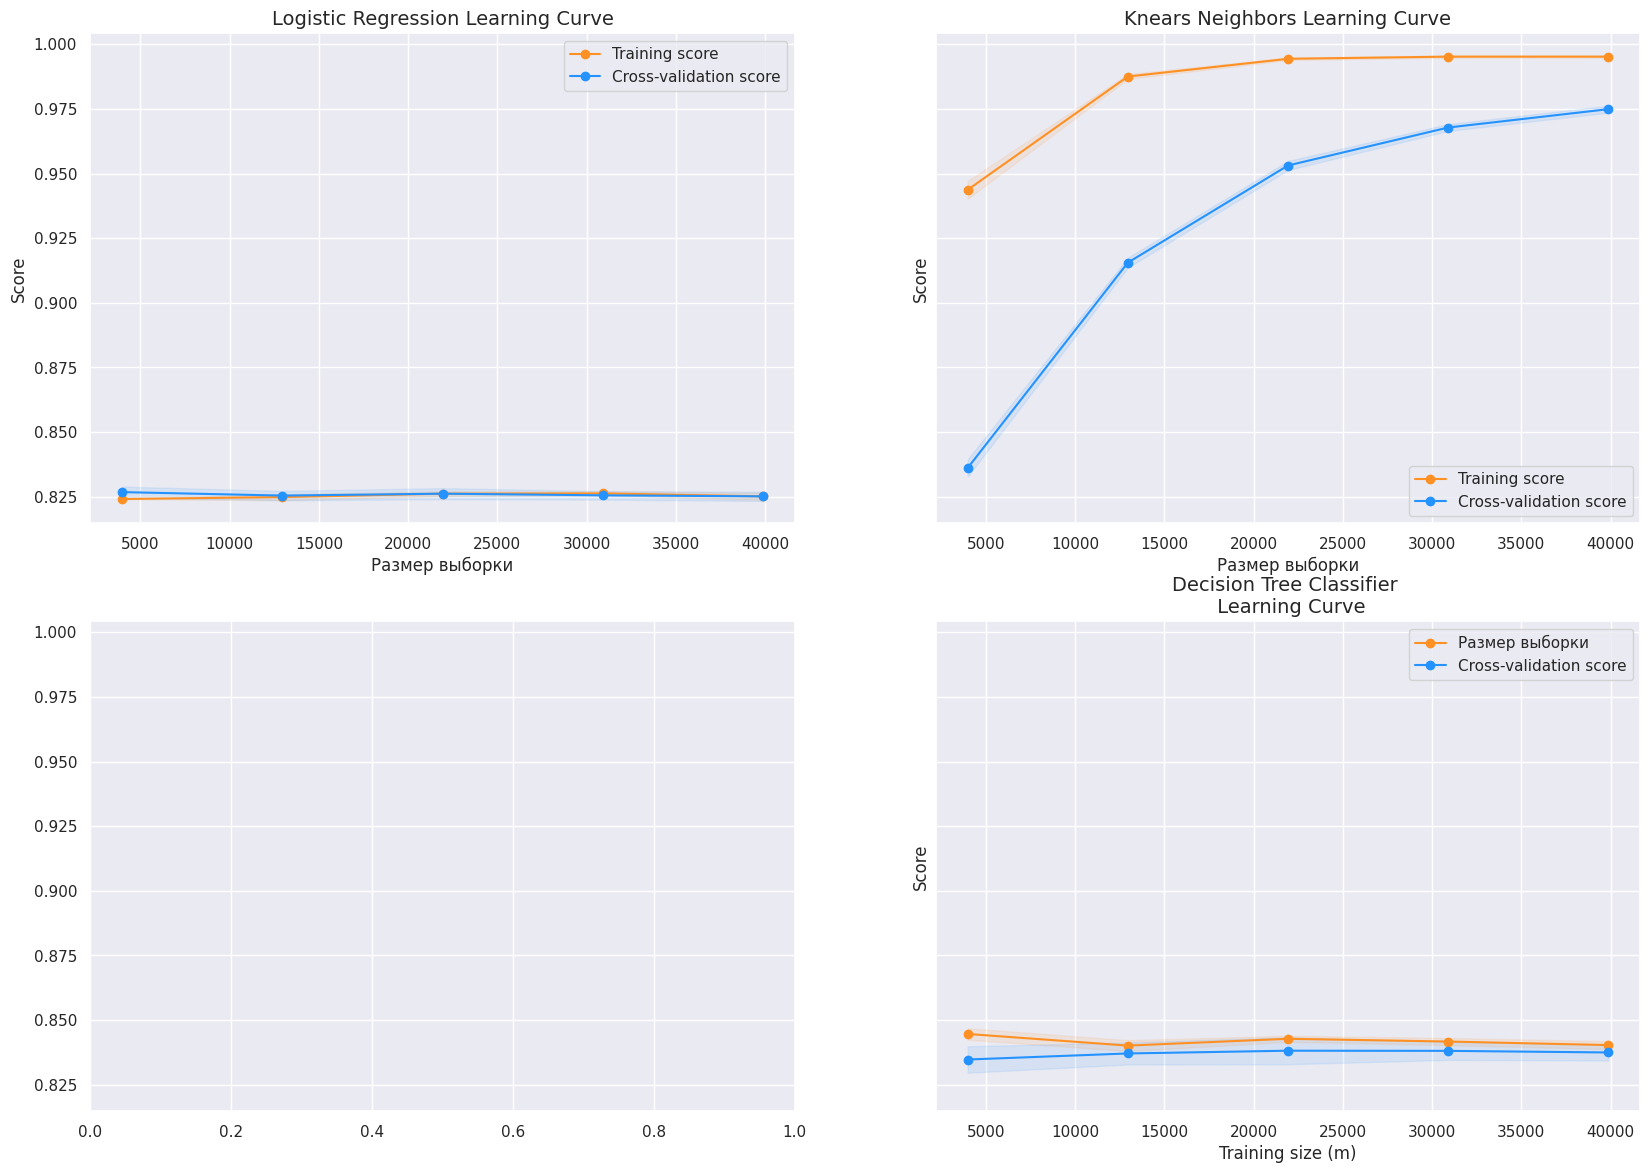

In [148]:
cv = ShuffleSplit(n_splits=100, test_size=0.2, random_state=42)
plot_learning_curves(log_reg, knears_neighbors, tree_clf, X=undersample_Xtrain, y=undersample_ytrain)

Тут хорошо себя показывает метод К ближайших соседей, и отчетливо виден процесс его обучения.

In [151]:
# Метод SMOTE для оверсемплинга вместо андерсемплинга.
#...
# сохраним параметры наших классификаторов, на которых они показали лучших результат с GridSearchCV

#dictionary of classifiers objects which we got in the above cell via GridSearchCV
#with the tuned parameters
tuned_classifiers = {
    "LogisiticRegression": log_reg,
    "Knears Neighbors": knears_neighbors,
    "DecisionTreeClassifier": tree_clf
}

#Making our Classifiers train with the tuned parameters
for key, classifier in tuned_classifiers.items():
    score = cross_val_score(classifier, xtrain, ytrain, cv=5)
    print(f'{key} Cross Validation Score: {round(score.mean() * 100, 2)}%')

LogisiticRegression Cross Validation Score: 82.51%
Knears Neighbors Cross Validation Score: 97.46%
DecisionTreeClassifier Cross Validation Score: 83.73%


In [159]:
#Over Sampling and under sampling libraries
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

#Machine learning Pipeline libraries
from imblearn.pipeline import Pipeline

# here we are using the imbalanced dataset
X = db2.drop("Claim", axis=1)
y = db2["Claim"]

# StratifiedKFold is used for cross validation
# This cross-validation object is a variation of KFold that returns stratified folds.
# The folds are made by preserving the percentage of samples for each class.
sss = StratifiedKFold(n_splits=10, shuffle=False)

# creating the object for Over Sampling the minority class
over = SMOTE(sampling_strategy=0.01,k_neighbors=5)

# creating the object for Under Sampling the majority class
under = RandomUnderSampler(sampling_strategy=0.5)

# iterating thru the dictionary of tuned classifiers
for key, classifier in tuned_classifiers.items():

    # list of steps to be provided to the ML Pipeline
    steps=[('o',over),('u',under),('model',classifier)]

    # Creating a ML Pipeline
    FiPipeline=Pipeline(steps=steps)

    # Cross validating the classifiers
    scores = cross_val_score(FiPipeline, X, y, cv=sss, error_score='raise')

    # Printing the mean accuracy score
    print(f"Classifier {key} has a training score of {round(scores.mean() * 100, 2)} % accuracy score")

ValueError: The specified ratio required to remove samples from the minority class while trying to generate new samples. Please increase the ratio.

А вот этот момент понять и заставить работать я никак не смог, извините.